### Feature Engineering

In [2]:
! pip install gensim matplotlib seaborn scikit-learn pyarrow

  Using cached matplotlib-3.11.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.9.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.3 kB)
  Using cached numpy-2.5.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached scipy-1.18.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached contourpy-1.4.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.66.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (130 kB)
  Using cached kiwisolver-1.5.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.1 kB)
  Usin

In [3]:
import duckdb, pandas as pd, numpy as np, os, matplotlib.pyplot as plt, seaborn as sns

In [9]:
import duckdb

try:
    con.close() 
except NameError:
    pass

con = duckdb.connect("../dataset/goodreads.db", read_only=True) 
con.sql("SET memory_limit='4GB'")
con.sql("SET temp_directory='duckdb_tmp'")

In [10]:
# load th data
os.makedirs("../figures", exist_ok=True)

# table without the text
df = con.sql("SELECT * EXCLUDE (description, title, author_name) FROM model_filled").df()

# one description per book for doc2vec
books = con.sql("SELECT DISTINCT book_id, description FROM model_filled").df()


raw = con.sql("""SELECT rating, num_pages, publication_year, book_avg_rating,
    book_ratings_count, book_text_reviews_count, author_avg_rating, author_ratings_count,
    u_mean_rating, u_std_rating, b_mean_rating, u_n_train, n_authors FROM model_data""").df()

nominal_stats = con.sql("""SELECT COUNT(DISTINCT language_code) langs, COUNT(DISTINCT publisher) publishers,
    COUNT(DISTINCT format) formats, COUNT(DISTINCT author_name) authors,
    COUNT(DISTINCT title) titles FROM model_filled""").df()


print(df.shape, books.shape); print(nominal_stats)  

(962899, 38) (22068, 2)
   langs  publishers  formats  authors  titles
0     29        2801       35     6573   20885


In [11]:
con.close()

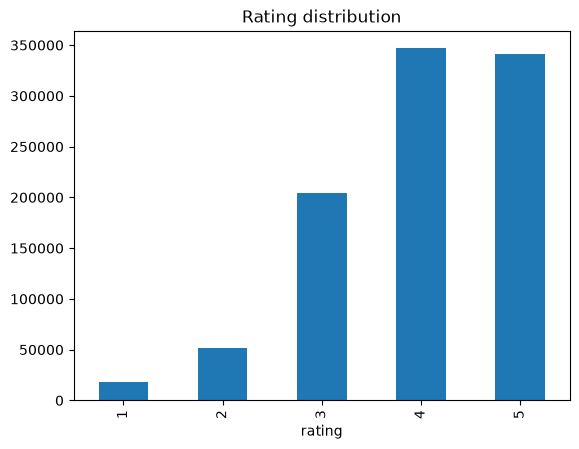

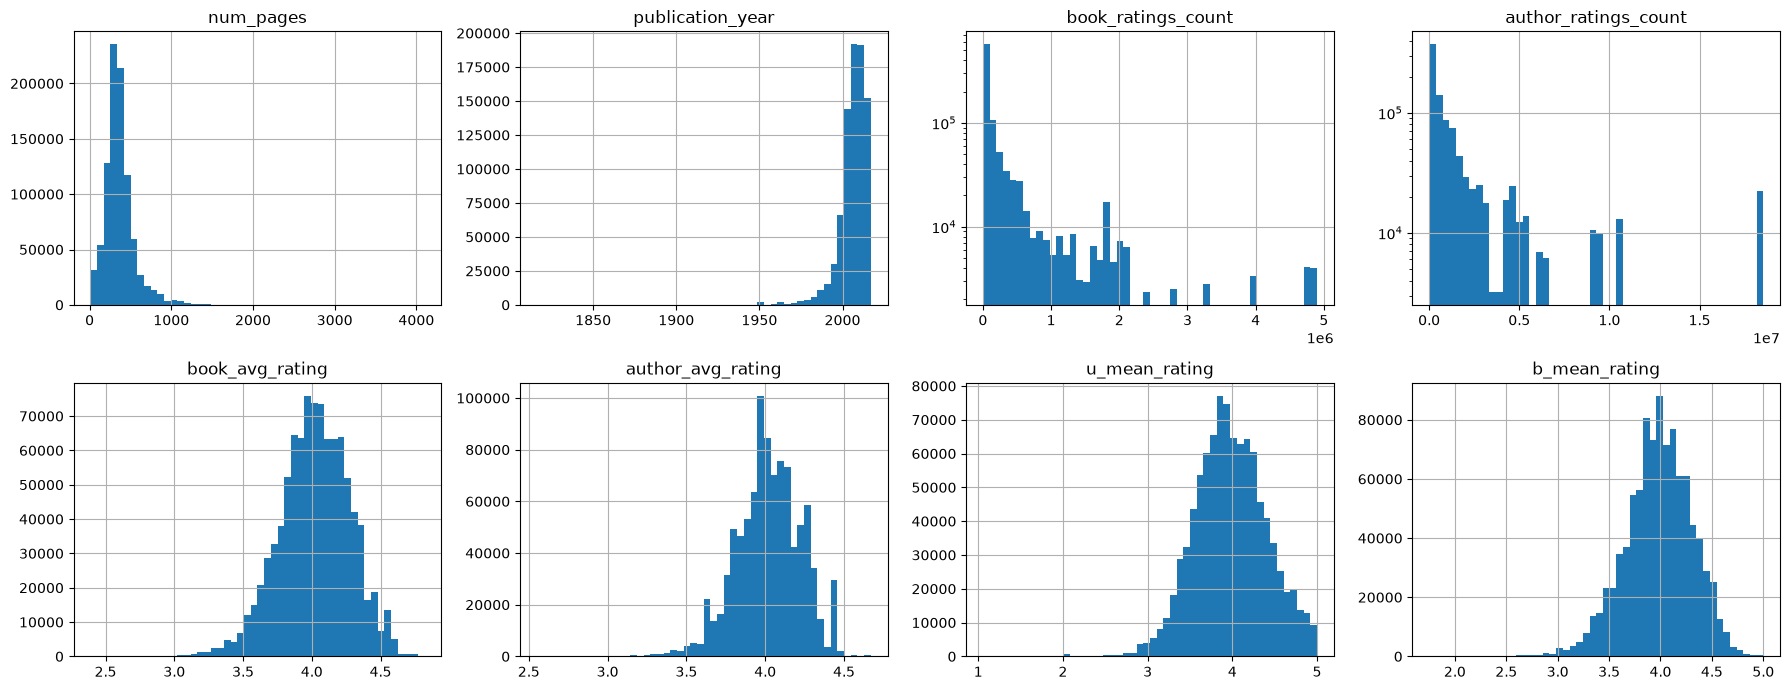

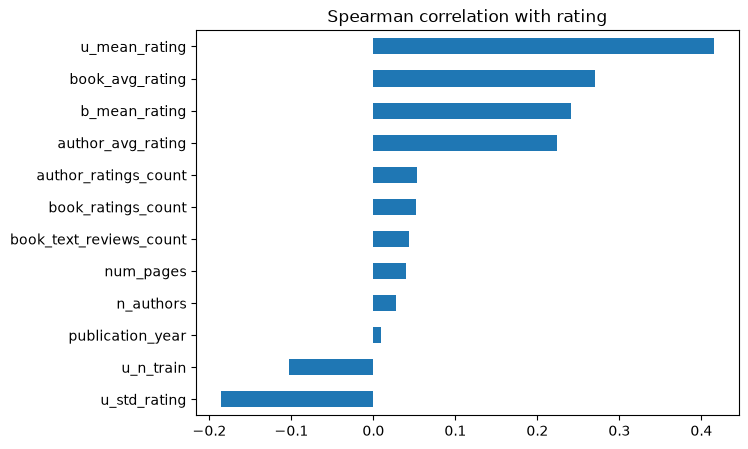

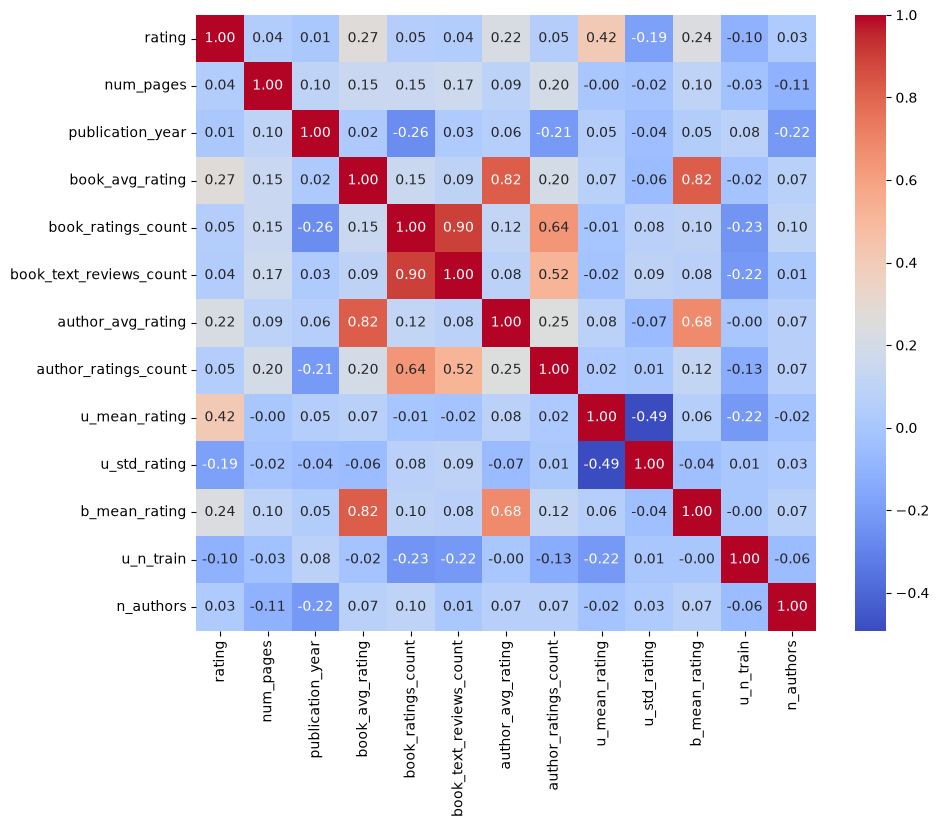

                            count           mean             std       min  \
rating                   962899.0       3.977761        0.976662       1.0   
num_pages                923432.0     369.856115      204.219951      10.0   
publication_year         822309.0    2005.759344        8.528262    1816.0   
book_avg_rating          962899.0        4.02185        0.254597      2.39   
book_ratings_count       962899.0  327102.938711   693749.028521     236.0   
book_text_reviews_count  962899.0    9633.228369    18028.610147       6.0   
author_avg_rating        962899.0       4.022156        0.206734      2.55   
author_ratings_count     962899.0  1874260.47858  3342415.993455    1474.0   
u_mean_rating            962899.0       3.979379        0.423756  1.055556   
u_std_rating             962899.0       0.859386        0.210801       0.0   
b_mean_rating            962899.0       3.978856        0.328742      1.75   
u_n_train                962899.0     178.755138      178.572979

In [13]:
# generate plots for thr reprt
# rating distribution
raw.rating.value_counts().sort_index().plot(kind="bar"); plt.title("Rating distribution")
plt.savefig("../figures/rating_dist.png", dpi=150, bbox_inches="tight"); plt.show()

# feature distributions 
cols = ["num_pages","publication_year","book_ratings_count","author_ratings_count",
        "book_avg_rating","author_avg_rating","u_mean_rating","b_mean_rating"]
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, c in zip(axes.ravel(), cols):
    raw[c].dropna().hist(bins=50, ax=ax); ax.set_title(c)
    if "count" in c: ax.set_yscale("log")
plt.tight_layout(); plt.savefig("../figures/distributions.png", dpi=150); plt.show()

#  correlation with lable
num = raw.columns.drop("rating")
lab = raw[num].corrwith(raw.rating, method="spearman").sort_values()
lab.plot(kind="barh", figsize=(7,5)); plt.title("Spearman correlation with rating")
plt.savefig("../figures/label_corr.png", dpi=150, bbox_inches="tight"); plt.show()

# cross correlation 
plt.figure(figsize=(10,8)); sns.heatmap(raw.corr(method="spearman"), annot=True, fmt=".2f", cmap="coolwarm")
plt.savefig("../figures/heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

print(raw.describe().T) 

In [14]:
# use doc2vec to encode descriptons
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from gensim.utils import simple_preprocess

books["description"] = books["description"].fillna("")

docs = [TaggedDocument(simple_preprocess(t), [i]) for i, t in enumerate(books.description)]
d2v = Doc2Vec(docs, vector_size=30, min_count=2, epochs=20, workers=4, seed=42)

vecs = np.array([d2v.dv[i] for i in range(len(docs))])
vecs[(books.description.str.len() == 0).values] = 0    

vec_df = pd.DataFrame(vecs, columns=[f"d2v_{i}" for i in range(30)])
vec_df["book_id"] = books.book_id.values

df = df.merge(vec_df, on="book_id", how="left")

In [15]:
# one hot encoding but only for top n values, the rest become other

for col, n in [("language_code", 10), ("format", 10), ("publisher", 15)]:
    df[col] = df[col].fillna("unknown")
    top = df.loc[df.split == "train", col].value_counts().head(n).index
    df[col] = df[col].where(df[col].isin(top), "other")
df = pd.get_dummies(df, columns=["language_code", "format", "publisher"], dtype=int)

# booleans 
for c in ["is_ebook","in_series","pages_missing","year_missing","desc_missing"]:
    df[c] = df[c].astype(int)

# columns to drop: Goodreads all-user book average (causes leakage) and constant columns
df = df.drop(columns=["book_avg_rating"])
const = [c for c in df.columns if df[c].nunique() == 1]; print("constant, dropped:", const)
df = df.drop(columns=const)

# log transform and standardize
from sklearn.preprocessing import StandardScaler
log_cols = ["num_pages","book_ratings_count","book_text_reviews_count","author_ratings_count",
            "author_text_reviews_count","u_n_train","b_n_train"]
for c in log_cols: df[c] = np.log1p(df[c])
scale_cols = log_cols + ["publication_year","author_avg_rating","u_mean_rating",
                         "u_std_rating","b_mean_rating","n_authors"]
sc = StandardScaler().fit(df.loc[df.split == "train", scale_cols])
df[scale_cols] = sc.transform(df[scale_cols])

constant, dropped: ['is_read']


In [16]:
#drop correlation >= 0.85
#exprt to parquet files
feat = df.drop(columns=["user_id","book_id","split","rating"])
c = feat[df.split == "train"].corrwith(df.loc[df.split == "train", "rating"]).abs().sort_values(ascending=False)
print(c.head(10)); print("Features >= 0.85:", list(c[c >= 0.85].index))

df = df.drop(columns=list(c[c >= 0.85].index))
df.to_parquet("../dataset/cleaned_dataset.parquet", index=False)
print(df.shape, df.split.value_counts().to_dict())
print(list(df.columns))

u_mean_rating                          0.408678
b_mean_rating                          0.243749
u_std_rating                           0.237014
author_avg_rating                      0.231064
u_n_train                              0.089295
p_fiction                              0.077626
publisher_Little, Brown and Company    0.055076
publisher_Scholastic Inc.              0.054998
author_text_reviews_count              0.052659
in_series                              0.051938
dtype: float64
Features >= 0.85: []
(962899, 101) {'train': 670109, 'test': 148614, 'val': 144176}
['user_id', 'book_id', 'rating', 'is_reviewed', 'is_ebook', 'book_ratings_count', 'book_text_reviews_count', 'in_series', 'n_authors', 'author_avg_rating', 'author_ratings_count', 'author_text_reviews_count', 'split', 'u_n_train', 'u_std_rating', 'b_n_train', 'u_mean_rating', 'b_mean_rating', 'num_pages', 'pages_missing', 'publication_year', 'year_missing', 'desc_missing', 'p_history', 'p_fiction', 'p_fantasy', 'p_mys